In [1]:
import os
import sys
import json
import time
from uuid import UUID

import pandas as pd
import numpy as np
from langchain.schema import LLMResult
from langchain.prompts import PromptTemplate
import plotly.express as px

from typing import Any, Union, Dict, List, Tuple
from functools import wraps
from datasets import load_from_disk, load_dataset, concatenate_datasets
from pathlib import Path


cwd = os.getcwd()


parent_dir = os.path.dirname(cwd)

print("Current Working Directory:", cwd)
print("Parent Directory:", parent_dir)
# HEX commands are too restrictive.
sys.path.append(os.path.abspath(parent_dir))

from nyx.data_generation.prompts import OPENAI_PREAMBLE
from nyx.utils import restructure_and_save_data

Current Working Directory: /Users/gtoth/PycharmProjects/demerzel/notebooks
Parent Directory: /Users/gtoth/PycharmProjects/demerzel


In [2]:
RATIONALES_SPLIT_STRING_EVAL = """Consider the coherence, accuracy, coverage, and overall quality of each summary and explain which one is better, in ONE or TWO SENTENCES. 
Then indicate the integer 1 or 2 for which summary is preferred."""  # 77s on 50

TASK_WITH_COT_LEE_ET_AL_EVAL = (
    """\nText - {text}
Summary 1 - {summary1}
Summary 2 - {summary2}
"""
    + f"""
{RATIONALES_SPLIT_STRING_EVAL}
Rationale:"""
)


PROMPT_STR_TEMPLATE = (
    (OPENAI_PREAMBLE + TASK_WITH_COT_LEE_ET_AL_EVAL)
    .replace('<|im_start|>user', '')
    .strip()
)

In [3]:
folder_labels = [
    'hf-baseline',
    'cot-baseline',
    'insights-120-only-positive',
    'insights-120-with-negatives',
    'insights-240', # there are also with negatives
    'insights-500', # there are also with negatives
]
phi_runs = [
    '8e9a5881d6c04fb6b20042829c9e5c3c',
    'c745c16cb14147649de39c37c90db8f5',
    'ccb3bd62cb454be49965529d56473fc5',
    'dd6d7dba1dff4630b4cf7c32b4848adf',
    'bbea9d66b20148a29fa41ff1cc586558',
    '64f781152e1c404aba665ad3707f4230',
]
qwen_runs = [
    'e7b8abb8e9434263a979a386d8c9ee82',
    'bd978ba45b24495db904ad394a8378a2',
    '95620e03ef074d429ff5df1070f5c715',
    '0c718a7ba4b84aca92c7fd3036f66e9f',
    'd3ed4259ac15478b849dac198d37441e',
    '3a522f64e8914808b903647ac3c736fd',
]

data_gen_runs = [
    '1c664836d1b245a8835808b5dfff02fe',
    'b592e2304b5c4b41a33236871ed4e195',
    '98608803ef184213bc1a13cf62cdf737',
    '39f5bda3ba5645cfb396e3d30d80a10e',
    '8cb27c1524fe4f7f817fa524859bab07',
]

In [4]:
# folder_labels = folder_labels[2:3]
# phi_runs = phi_runs[2:3]
# qwen_runs = qwen_runs[2:3]
# del models['qwen-2-7b']
# print(qwen_runs)


models_configs = {'qwen-2-7b': qwen_runs, 'phi-1-5': phi_runs}

def load_data_sft_json_files_into_dict(
    models: Dict[str, List[str]],
    file_name: str = None,
    use_model_name_mapping: bool = False,
    sub_path: str = '02-sft',
    parent_dir: str = parent_dir,
) -> Dict:
    renaming_models = {'qwen-2-7b': 'qwen2-7b'}
    if file_name is not None:
        qwen_file_name = (
            f'qwen2-7b-{file_name}'
            if use_model_name_mapping is True
            else f'{file_name}'
        )
        phi_file_name = (
            f'phi-1-5-{file_name}' if use_model_name_mapping is True else f'{file_name}'
        )
    else:
        qwen_file_name = f'qwen2-7b-ppo-telemetry'
        phi_file_name = f'phi-1-5-ppo-telemetry'

    # parent_dir = '.'
    evaluation_results_dict = {}

    for model, runs in models.items():
        file_name = qwen_file_name if model == 'qwen-2-7b' else phi_file_name

        for run_id, run_type in zip(runs, folder_labels):

            print(model, run_type, run_id[:8])

            with open(
                f'{parent_dir}/results-section/{sub_path}/{model}/{run_id}/metrics/{file_name}.json'
            ) as f:
                ppo_results = json.load(f)

            evaluation_results_dict[f'{model}_{run_type}'] = ppo_results
    return evaluation_results_dict
    

def load_json_files_into_dict(
    models: Dict[str, List[str]],
    file_name: str = None,
    use_model_name_mapping: bool = False,
    sub_path: str = '03-reward-modelling-and-reinforcement-learning',
    parent_dir: str = parent_dir,
) -> Dict:
    renaming_models = {'qwen-2-7b': 'qwen2-7b'}
    if file_name is not None:
        qwen_file_name = (
            f'qwen2-7b-{file_name}'
            if use_model_name_mapping is True
            else f'{file_name}'
        )
        phi_file_name = (
            f'phi-1-5-{file_name}' if use_model_name_mapping is True else f'{file_name}'
        )
    else:
        qwen_file_name = f'qwen2-7b-ppo-telemetry'
        phi_file_name = f'phi-1-5-ppo-telemetry'

    # parent_dir = '.'
    evaluation_results_dict = {}

    for model, runs in models.items():
        file_name = qwen_file_name if model == 'qwen-2-7b' else phi_file_name

        for run_id, run_type in zip(runs, folder_labels):

            print(model, run_type, run_id[:8])

            with open(
                f'{parent_dir}/results-section/{sub_path}/{model}/{run_type}/{run_id}/metrics/{file_name}.json'
            ) as f:
                ppo_results = json.load(f)

            evaluation_results_dict[f'{model}_{run_type}'] = ppo_results
    return evaluation_results_dict


def load_generated_datasets_and_metrics(
    models: Dict[str, List[str]],
    parent_dir: str = parent_dir,
    # metrics_file_name: str = 'labeller-results',
    # use_model_name_mapping: bool = False,
) -> Tuple:

    # parent_dir = '.'
    metrics_file_name = 'labeller-results'
    dataset_file_name = 'data'
    datasets = []
    evaluation_results_dict = {}

    for model, runs in models.items():

        for run_id, run_type in zip(data_gen_runs, folder_labels[1:]):

            print(model, run_type, run_id[:8])
            metrics_path = f'{parent_dir}/results-section/01-data-generation/{run_type}/{run_id}/metrics/{metrics_file_name}.json'

            with open(metrics_path) as f:
                labeller_results = json.load(f)

            evaluation_results_dict[f'{model}_{run_type}'] = labeller_results

    for model, runs in models.items():
        if model == list(models.keys())[0]:
            for run_id, run_type in zip(data_gen_runs, folder_labels[1:]):
                dataset_path = f'{parent_dir}/results-section/01-data-generation/{run_type}/{run_id}/data/labelled-train-data'

                comparison_dataset = load_from_disk(dataset_path)['train']

                comparison_dataset = comparison_dataset.add_column(
                    name="model",
                    column=['phi-3-medium' for _ in range(len(comparison_dataset))],
                )
                comparison_dataset = comparison_dataset.add_column(
                    name="run_type",
                    column=[run_type for _ in range(len(comparison_dataset))],
                )
                datasets.append(comparison_dataset)

    return evaluation_results_dict, concatenate_datasets(datasets)

# SFT

In [5]:
models_sft_configs = {'qwen2-7b': ['ae517069e3734bb4884dfa7fed5db18f'], 'phi-1-5': ['be140fa23e9e4452a7801060e9e7d6ba']}
sft_results = load_data_sft_json_files_into_dict(
    models=models_sft_configs,
    file_name='sft-results',
    use_model_name_mapping=False,
    sub_path = '02-sft',
    # parent_dir: str = parent_dir,
)

qwen2-7b hf-baseline ae517069
phi-1-5 hf-baseline be140fa2


In [6]:
sft_results_dict = {'model': [], 'sft': [], 'rouge1': [], 'rouge2': [], 'rougeL': [], 'rougeLsum': []}
for key, value in sft_results.items():
    sft_results_dict['model'].append(key.split('_')[0])
    sft_results_dict['sft'].append('before')
    sft_results_dict['rouge1'].append(value['rouge-metric-baseline-model']['rouge1'])
    sft_results_dict['rouge2'].append(value['rouge-metric-baseline-model']['rouge2'])
    sft_results_dict['rougeL'].append(value['rouge-metric-baseline-model']['rougeL'])
    sft_results_dict['rougeLsum'].append(value['rouge-metric-baseline-model']['rougeLsum'])
    
    sft_results_dict['model'].append(key.split('_')[0])
    sft_results_dict['sft'].append('after')
    sft_results_dict['rouge1'].append(value['rouge-metric-sft-model']['rouge1'])
    sft_results_dict['rouge2'].append(value['rouge-metric-sft-model']['rouge2'])
    sft_results_dict['rougeL'].append(value['rouge-metric-sft-model']['rougeL'])
    sft_results_dict['rougeLsum'].append(value['rouge-metric-sft-model']['rougeLsum'])

sft_metrics_pd_df = pd.DataFrame.from_dict(sft_results_dict)
sft_metrics_pd_df.to_csv('sft-metrics.csv', index=False)
sft_metrics_pd_df

,model,sft,rouge1,rouge2,rougeL,rougeLsum
0,qwen2-7b,before,0.14,0.05,0.10,0.11
1,qwen2-7b,after,0.14,0.05,0.10,0.11
2,phi-1-5,before,0.15,0.05,0.10,0.11
3,phi-1-5,after,0.10,0.03,0.07,0.08


# RM

## Data Generation

In [7]:
COMPARISON_DATA_PATH = "./data/restructured_openai_comparison_data"
comparison_data_path = Path(COMPARISON_DATA_PATH)
if not comparison_data_path.is_dir():
    dataset = load_dataset("openai/summarize_from_feedback", name='comparisons')
    print("Restructuring and saving OpenAI labelled reddit summarisation data.")
    restructure_and_save_data(dataset)

total_comparison_dataset = load_from_disk(COMPARISON_DATA_PATH)
total_comparison_dataset["train"] = total_comparison_dataset["train"].select(
    range(10_000)
)

total_comparison_dataset["train"] = total_comparison_dataset["train"].add_column(
    name="nth_example",
    column=[i for i in range(len(total_comparison_dataset["train"]))],
)
print(total_comparison_dataset["train"])
training_data_pd_df = total_comparison_dataset['train'].to_pandas()

training_data_pd_df[
    ['candidate_summary_1', 'candidate_summary_2', 'post', 'nth_example']
].head()

Dataset({
    features: ['subreddit', 'post', 'choice', 'candidate_summary_1', 'candidate_summary_2', 'nth_example'],
    num_rows: 10000
})


/Users/gtoth/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/pandas/core/frame.py:706: DeprecationWarning: Passing a BlockManager to DataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(


,candidate_summary_1,candidate_summary_2,post,nth_example
0,Mum is mad at me for not flying on my own tri...,I have made sure my mother is comfortable wit...,My boyfriend and I are long distance. We have ...,0
1,I have made sure my mother is comfortable wit...,mum isn't speaking to me because I booked a f...,My boyfriend and I are long distance. We have ...,1
2,mum isn't speaking to me because I booked a f...,Mum thought I was going to road trip with my ...,My boyfriend and I are long distance. We have ...,2
3,Mum thought I was going to road trip with my ...,Mum is mad at me for not flying on my own tri...,My boyfriend and I are long distance. We have ...,3
4,My landlord is harassing me and my neighbours...,landlord pretended to be another tenant and w...,My landlord left a falsified message taped to ...,4


In [8]:
data_gen_metrics, combined_dg_dataset = load_generated_datasets_and_metrics(models=models_configs)
dg_datasets_pd_df = combined_dg_dataset.to_pandas()

qwen-2-7b cot-baseline 1c664836
qwen-2-7b insights-120-only-positive b592e230
qwen-2-7b insights-120-with-negatives 98608803
qwen-2-7b insights-240 39f5bda3
qwen-2-7b insights-500 8cb27c15
phi-1-5 cot-baseline 1c664836
phi-1-5 insights-120-only-positive b592e230
phi-1-5 insights-120-with-negatives 98608803
phi-1-5 insights-240 39f5bda3
phi-1-5 insights-500 8cb27c15


/Users/gtoth/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/pandas/core/frame.py:706: DeprecationWarning: Passing a BlockManager to DataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(


In [78]:
dg_datasets_pd_df.head()

,subreddit,post,choice,candidate_summary_1,candidate_summary_2,ai_choice,constant_col,nth_retry,ordered_prompt_used_to_predict,reversed_prompt_used_to_predict,model,run_type,ai_choice_for_prompt,incorrect_prediction
0,AskReddit,"I'm typing this shaking right now, so bear wit...",1,"My best friend's mom left him, I'm freaking out.","best friend's mom left him, I'm worried for h...",0,1,0,<bos><start_of_turn>user\nA good summary is a...,<bos><start_of_turn>user\nA good summary is a...,phi-3-medium,cot-baseline,NaN,None
1,AskReddit,"I'm typing this shaking right now, so bear wit...",0,"best friend's mom left him, I'm worried for h...",My best friend's mom left him for another guy...,0,1,0,<bos><start_of_turn>user\nA good summary is a...,<bos><start_of_turn>user\nA good summary is a...,phi-3-medium,cot-baseline,NaN,None
2,AskReddit,"I'm typing this shaking right now, so bear wit...",0,"read the whole thing, it's important. Friend'...","My best friend's mom left him, I'm freaking out.",1,1,0,<bos><start_of_turn>user\nA good summary is a...,<bos><start_of_turn>user\nA good summary is a...,phi-3-medium,cot-baseline,NaN,None
3,AskReddit,"I'm typing this shaking right now, so bear wit...",1,My best friend's mom left him for another guy...,"read the whole thing, it's important. Friend'...",1,1,0,<bos><start_of_turn>user\nA good summary is a...,<bos><start_of_turn>user\nA good summary is a...,phi-3-medium,cot-baseline,NaN,None
4,AskReddit,"I'm typing this shaking right now, so bear wit...",1,"My best friend's mom left him, I'm freaking out.","best friend's mom left him, I'm worried for h...",0,1,0,<bos><start_of_turn>user\nA good summary is a...,<bos><start_of_turn>user\nA good summary is a...,phi-3-medium,cot-baseline,NaN,None


In [35]:
dg_datasets_pd_df['choice'].mean()

0.5012

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef


# dg_datasets_pd_df.head()
# overall results
# vs. results from reflexion or insights
def compute_confusion_matrix_elements(y_true, y_pred):
    TP = ((y_true == 1) & (y_pred == 1)).sum()
    TN = ((y_true == 0) & (y_pred == 0)).sum()
    FP = ((y_true == 0) & (y_pred == 1)).sum()
    FN = ((y_true == 1) & (y_pred == 0)).sum()
    return TP, TN, FP, FN


def compute_metrics(group):
    y_true = group['choice']
    y_pred = group['ai_choice']

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    mcc = (
        matthews_corrcoef(y_true, y_pred) if len(y_true.unique()) > 1 else 0
    )  # Avoid MCC for single-class cases
    TP, TN, FP, FN = compute_confusion_matrix_elements(y_true, y_pred)
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    return pd.Series(
        {
            'accuracy': round(accuracy, 4),
            'precision': round(precision, 4),
            'recall': round(recall, 4),
            'f1_score': round(f1, 4),
            'mcc': round(mcc, 4),
            'true_positives': int(TP),
            'true_negatives': int(TN),
            'false_positives': int(FP),
            'false_negatives': int(FN),
        }
    )


metrics_df = (
    dg_datasets_pd_df.groupby(["model", "run_type"])
    .apply(compute_metrics)
    .reset_index()
)

/Users/gtoth/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:605: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/Users/gtoth/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:614: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
/Users/gtoth/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:605: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/Users/gtoth/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:614: DeprecationWarning: is_sparse is deprecated and will be removed in a future vers

In [10]:
metrics_df.sort_values(['model', 'run_type'], ascending=[False, True], inplace=True)
metrics_df.to_csv('overall-data-generation-results.csv', index=False)
metrics_df

,model,run_type,accuracy,precision,recall,f1_score,mcc,true_positives,true_negatives,false_positives,false_negatives
0,phi-3-medium,cot-baseline,0.4884,0.4696,0.1602,0.2389,-0.0287,803.0,4081.0,907.0,4209.0
1,phi-3-medium,insights-120-only-positive,0.4961,0.4899,0.1303,0.2058,-0.0089,653.0,4308.0,680.0,4359.0
2,phi-3-medium,insights-120-with-negatives,0.4985,0.4983,0.0872,0.1484,-0.0018,437.0,4548.0,440.0,4575.0
3,phi-3-medium,insights-240,0.4969,0.4889,0.0838,0.1431,-0.0075,420.0,4549.0,439.0,4592.0
4,phi-3-medium,insights-500,0.5130,0.5978,0.0866,0.1513,0.0541,434.0,4696.0,292.0,4578.0


In [11]:
# print(px.colors.qualitative.Plotly)

In [12]:
# n_colors = len(folder_labels)
# colorscale = px.colors.qualitative.Plotly  # px.colors.sample_colorscale("Plotly", [n/(n_colors -1) for n in range(n_colors)])
# colordict = {f:colorscale[i] for i, f in enumerate(folder_labels)}

colors = px.colors.qualitative.Plotly

# Manually map the categories to specific colors in the Plotly color scale
color_map = {
    'hf-baseline': colors[0],
    'cot-baseline': colors[1],
    'insights-120-only-positive': colors[2],
    'insights-120-with-negatives': colors[3],
    'insights-240': colors[4],
    'insights-500': colors[5]
}
# # plotly figure
# fig = px.bar(
#         fruit_data,
#         x="Day",
#         y="Value",
#         color = 'Fruit',
#         color_discrete_map = colordict
#       )
# fig.show()

/Users/gtoth/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/plotly/express/_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/Users/gtoth/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/plotly/io/_renderers.py:395: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.



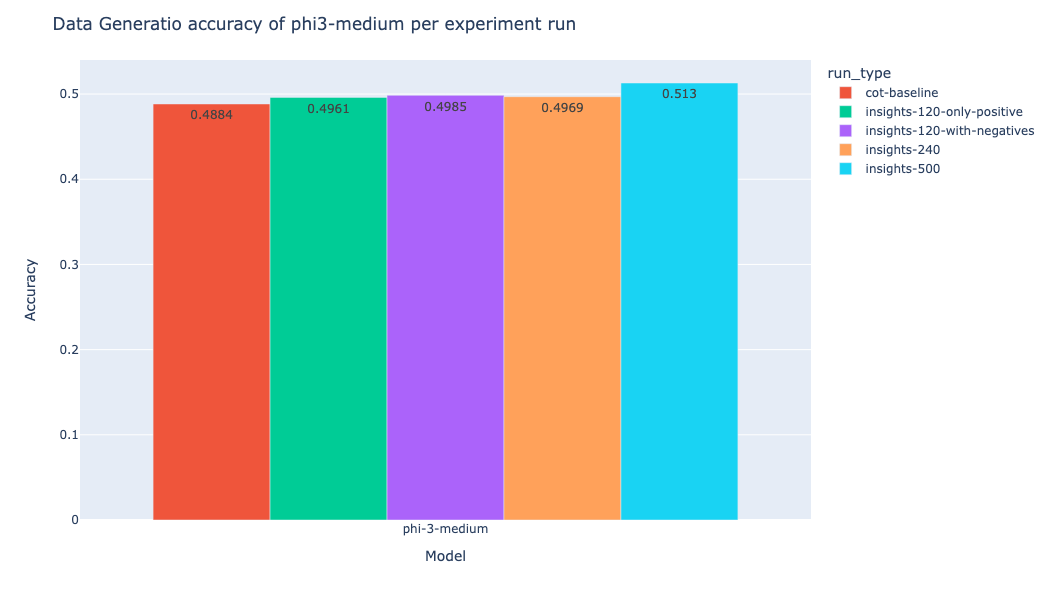

In [15]:
fig = px.bar(
    metrics_df,
    x="model",
    y="accuracy",
    color="run_type",
    barmode="group",
    # facet_row="time",
    # facet_col="model",
    # category_orders={"day": ["Thur", "Fri", "Sat", "Sun"],
    #                  "time": ["Lunch", "Dinner"]}
    color_discrete_map=color_map,
    text='accuracy',
)

fig.update_layout(title_text=f"Data Generatio accuracy of phi3-medium per experiment run")

# Set x-axis title
fig.update_xaxes(title_text="Model")

# Set y-axes titles
fig.update_yaxes(title_text="Accuracy", secondary_y=False)
# fig.update_yaxes(title_text="Rewards Mean", secondary_y=True)
fig.update_layout(
    autosize=False,
    width=1_000,
    height=600,
)
fig.show()

In [16]:
reflexion_metrics_df = (
    dg_datasets_pd_df.groupby(["model", "run_type", "nth_retry"])
    .apply(compute_metrics)
    .reset_index()
)

/Users/gtoth/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:605: DeprecationWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

/Users/gtoth/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:614: DeprecationWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

/Users/gtoth/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:605: DeprecationWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

/Users/gtoth/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:614: DeprecationWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

/Users/gtoth/miniconda3/envs/tf-gpu/lib/python3.10/site-

In [17]:
reflexion_metrics_df['reflexion'] = reflexion_metrics_df['nth_retry'] == 1
metrics_df.to_csv('reflexion-data-generation-results.csv', index=False)
reflexion_metrics_df

,model,run_type,nth_retry,accuracy,precision,recall,f1_score,mcc,true_positives,true_negatives,false_positives,false_negatives,reflexion
0,phi-3-medium,cot-baseline,0,0.4884,0.4696,0.1602,0.2389,-0.0287,803.0,4081.0,907.0,4209.0,False
1,phi-3-medium,insights-120-only-positive,0,0.4955,0.4801,0.1267,0.2005,-0.0149,628.0,4292.0,680.0,4329.0,False
2,phi-3-medium,insights-120-only-positive,1,0.5775,1.0000,0.4545,0.6250,0.3976,25.0,16.0,0.0,30.0,True
3,phi-3-medium,insights-120-with-negatives,0,0.4989,0.4811,0.0825,0.1409,-0.0102,408.0,4546.0,440.0,4535.0,False
4,phi-3-medium,insights-120-with-negatives,1,0.4366,1.0000,0.4203,0.5918,0.1415,29.0,2.0,0.0,40.0,True
5,phi-3-medium,insights-240,0,0.4962,0.4630,0.0764,0.1311,-0.0208,375.0,4521.0,435.0,4535.0,False
6,phi-3-medium,insights-240,1,0.5448,0.9184,0.4412,0.5960,0.2799,45.0,28.0,4.0,57.0,True
7,phi-3-medium,insights-500,0,0.5144,0.5621,0.0715,0.1269,0.0356,344.0,4668.0,268.0,4464.0,False
8,phi-3-medium,insights-500,1,0.4609,0.7895,0.4412,0.5660,-0.0165,90.0,28.0,24.0,114.0,True


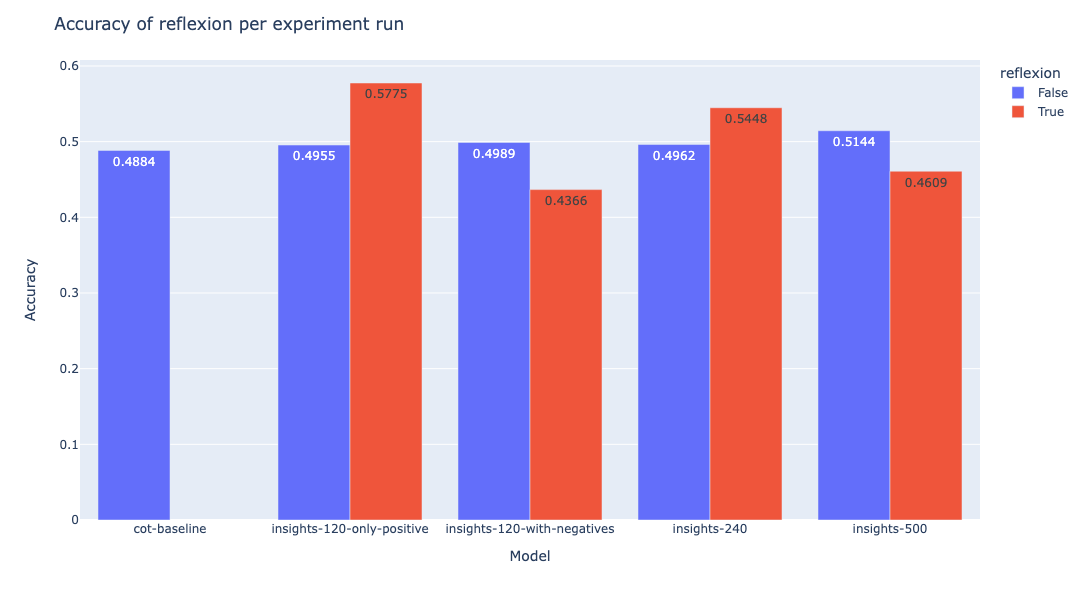

In [177]:
fig = px.bar(
    reflexion_metrics_df,
    x="run_type",
    y="accuracy",
    color="reflexion",
    barmode="group",
    # facet_row="time",
    # facet_col="model",
    # category_orders={"day": ["Thur", "Fri", "Sat", "Sun"],
    #                  "time": ["Lunch", "Dinner"]}
    text='accuracy',
)

fig.update_layout(title_text=f"Accuracy of reflexion per experiment run")

# Set x-axis title
fig.update_xaxes(title_text="Model")

# Set y-axes titles
fig.update_yaxes(title_text="Accuracy", secondary_y=False)
# fig.update_yaxes(title_text="Rewards Mean", secondary_y=True)
fig.update_layout(autosize=False, width=1_000, height=600, barmode='group')
fig.show()

In [18]:
joined_dg_df = dg_datasets_pd_df.merge(
    training_data_pd_df[
        ['candidate_summary_1', 'candidate_summary_2', 'post', 'choice', 'nth_example']
    ],
    how='inner',
    on=['candidate_summary_1', 'candidate_summary_2', 'post', 'choice'],
)

joined_dg_df['step_size'] = np.where(
    joined_dg_df['run_type'].str.contains('insights'),
    (joined_dg_df['run_type'].str.split('-').str[1]),
    0,
)

# joined_dg_df.head()
joined_dg_df['step_size'] = joined_dg_df['step_size'].astype('int32')
# joined_dg_df['step_size'].unique()
joined_dg_df['insights_generation_stage'] = (
    joined_dg_df['nth_example'] < joined_dg_df['step_size']
)

insights_metrics_df = (
    joined_dg_df.groupby(["model", "run_type", "insights_generation_stage"])
    .apply(compute_metrics)
    .reset_index()
)

/Users/gtoth/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:605: DeprecationWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

/Users/gtoth/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:614: DeprecationWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

/Users/gtoth/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:605: DeprecationWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

/Users/gtoth/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:614: DeprecationWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

/Users/gtoth/miniconda3/envs/tf-gpu/lib/python3.10/site-

In [19]:
insights_metrics_df.to_csv('insights-data-generation-results.csv', index=False)
insights_metrics_df

,model,run_type,insights_generation_stage,accuracy,precision,recall,f1_score,mcc,true_positives,true_negatives,false_positives,false_negatives
0,phi-3-medium,cot-baseline,False,0.4797,0.4014,0.1366,0.2038,-0.0769,2954.0,18323.0,4405.0,18676.0
1,phi-3-medium,insights-120-only-positive,False,0.4923,0.4264,0.1227,0.1906,-0.0490,2601.0,18826.0,3499.0,18597.0
2,phi-3-medium,insights-120-only-positive,True,0.9581,1.0000,0.9190,0.9578,0.9195,397.0,403.0,0.0,35.0
3,phi-3-medium,insights-120-with-negatives,False,0.5034,0.4436,0.0774,0.1318,-0.0265,1640.0,20268.0,2057.0,19558.0
4,phi-3-medium,insights-120-with-negatives,True,0.7126,1.0000,0.4444,0.6154,0.5278,192.0,403.0,0.0,240.0
5,phi-3-medium,insights-240,False,0.4861,0.3444,0.0482,0.0846,-0.0805,1013.0,19736.0,1928.0,20007.0
6,phi-3-medium,insights-240,True,0.7981,0.9121,0.4934,0.6404,0.5639,301.0,1035.0,29.0,309.0
7,phi-3-medium,insights-500,False,0.5126,0.5339,0.0713,0.1258,0.0223,1418.0,19301.0,1238.0,18461.0
8,phi-3-medium,insights-500,True,0.6997,0.7474,0.4900,0.5919,0.3910,858.0,1899.0,290.0,893.0


/Users/gtoth/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/plotly/express/_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/Users/gtoth/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/plotly/io/_renderers.py:395: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.



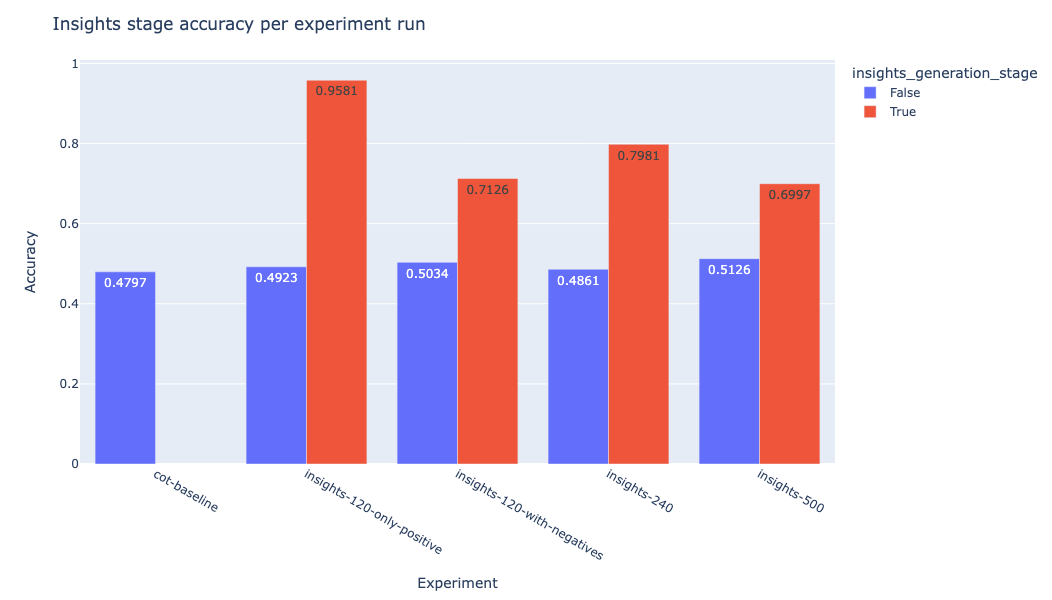

In [20]:
fig = px.bar(
    insights_metrics_df,
    x="run_type",
    y="accuracy",
    color="insights_generation_stage",
    barmode="group",
    # facet_row="time",
    # facet_col="model",
    # category_orders={"day": ["Thur", "Fri", "Sat", "Sun"],
    #                  "time": ["Lunch", "Dinner"]}
    text='accuracy',
)

fig.update_layout(title_text=f"Insights stage accuracy per experiment run")

# Set x-axis title
fig.update_xaxes(title_text="Experiment")

# Set y-axes titles
fig.update_yaxes(title_text="Accuracy", secondary_y=False)
# fig.update_yaxes(title_text="Rewards Mean", secondary_y=True)
fig.update_layout(autosize=False, width=1_000, height=600, barmode='group')
fig.show()

## RM training

In [21]:
rm_results = load_json_files_into_dict(
    models=models_configs,
    file_name='reward-model-results',
    # use_model_name_mapping=False,
    # sub_path: str = '03-reward-modelling-and-reinforcement-learning',
)

qwen-2-7b hf-baseline e7b8abb8
qwen-2-7b cot-baseline bd978ba4
qwen-2-7b insights-120-only-positive 95620e03
qwen-2-7b insights-120-with-negatives 0c718a7b
qwen-2-7b insights-240 d3ed4259
qwen-2-7b insights-500 3a522f64
phi-1-5 hf-baseline 8e9a5881
phi-1-5 cot-baseline c745c16c
phi-1-5 insights-120-only-positive ccb3bd62
phi-1-5 insights-120-with-negatives dd6d7dba
phi-1-5 insights-240 bbea9d66
phi-1-5 insights-500 64f78115


In [22]:
rm_metrics_dict = {
    'model': [],
    'run_type': [],
    'accuracy': [],
    'recall': [],
    'f1-score': [],
    'mcc': [],
    'tn': [],
    'fp': [],
    'fn': [],
    'tp': [],
}

for model_name, metrics in rm_results.items():
    rm_metrics_dict['accuracy'].append(metrics['classification_report']['accuracy'])
    rm_metrics_dict['f1-score'].append(
        metrics['classification_report']['weighted avg']['f1-score']
    )
    rm_metrics_dict['recall'].append(
        metrics['classification_report']['weighted avg']['recall']
    )
    rm_metrics_dict['mcc'].append(metrics['mcc'])
    rm_metrics_dict['tp'].append(metrics['tp'])
    rm_metrics_dict['fp'].append(metrics['fp'])
    rm_metrics_dict['fn'].append(metrics['fn'])
    rm_metrics_dict['tn'].append(metrics['tn'])
    rm_metrics_dict['run_type'].append(model_name.split('_')[1])
    rm_metrics_dict['model'].append(model_name.split('_')[0])

rm_pd_df = pd.DataFrame.from_dict(rm_metrics_dict)
rm_pd_df.sort_values(['model', 'accuracy'], ascending=[True, True], inplace=True)
rm_pd_df.to_csv('rm-results.csv', index=False)
rm_pd_df

,model,run_type,accuracy,recall,f1-score,mcc,tn,fp,fn,tp
8,phi-1-5,insights-120-only-positive,0.496025,0.496025,0.496056,-0.007598,314,329,305,310
10,phi-1-5,insights-240,0.496820,0.496820,0.496844,-0.005972,314,329,304,311
9,phi-1-5,insights-120-with-negatives,0.498410,0.498410,0.498381,-0.002580,312,331,300,315
11,phi-1-5,insights-500,0.499205,0.499205,0.499186,-0.001024,313,330,300,315
7,phi-1-5,cot-baseline,0.500000,0.500000,0.499991,0.000531,314,329,300,315
6,phi-1-5,hf-baseline,0.522258,0.522258,0.522309,0.044351,338,305,296,319
0,qwen-2-7b,hf-baseline,0.511924,0.511924,0.511973,0.024067,326,317,297,318
2,qwen-2-7b,insights-120-only-positive,0.512719,0.512719,0.512710,0.025982,322,321,292,323
4,qwen-2-7b,insights-240,0.514308,0.514308,0.514344,0.028945,326,317,294,321
1,qwen-2-7b,cot-baseline,0.516693,0.516693,0.516753,0.033395,332,311,297,318


/Users/gtoth/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/plotly/express/_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/Users/gtoth/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/plotly/io/_renderers.py:395: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.



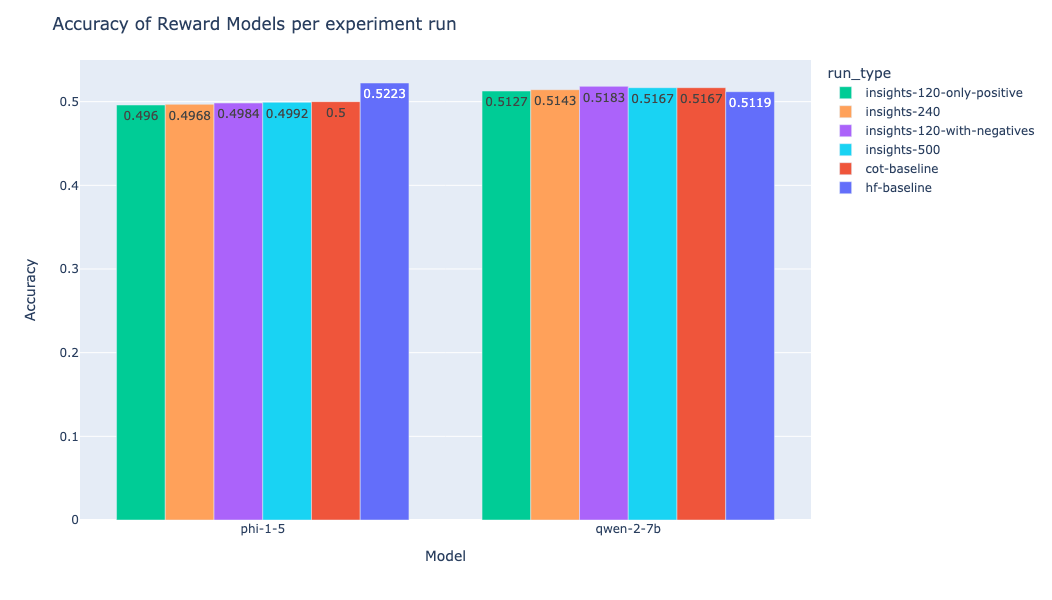

In [24]:
fig = px.bar(
    rm_pd_df.sort_values(['model', 'accuracy'], ascending=[True, True]).round(4),
    x="model",
    y="accuracy",
    color="run_type",
    barmode="group",
    # facet_row="time",
    # facet_col="model",
    # category_orders={"day": ["Thur", "Fri", "Sat", "Sun"],
    #                  "time": ["Lunch", "Dinner"]}
    color_discrete_map=color_map,
    text='accuracy',
)

fig.update_layout(title_text=f"Accuracy of Reward Models per experiment run")

# Set x-axis title
fig.update_xaxes(title_text="Model")

# Set y-axes titles
fig.update_yaxes(title_text="Accuracy", secondary_y=False)
# fig.update_yaxes(title_text="Rewards Mean", secondary_y=True)
fig.update_layout(
    autosize=False,
    width=1_000,
    height=600,
)
fig.show()

# PPO

## Training metrics

In [29]:
ppo_telemetry_dict = load_json_files_into_dict(models_configs)
list(ppo_telemetry_dict.keys())[0]

qwen-2-7b hf-baseline e7b8abb8
qwen-2-7b cot-baseline bd978ba4
qwen-2-7b insights-120-only-positive 95620e03
qwen-2-7b insights-120-with-negatives 0c718a7b
qwen-2-7b insights-240 d3ed4259
qwen-2-7b insights-500 3a522f64
phi-1-5 hf-baseline 8e9a5881
phi-1-5 cot-baseline c745c16c
phi-1-5 insights-120-only-positive ccb3bd62
phi-1-5 insights-120-with-negatives dd6d7dba
phi-1-5 insights-240 bbea9d66
phi-1-5 insights-500 64f78115


dict_keys(['qwen-2-7b_hf-baseline', 'qwen-2-7b_cot-baseline', 'qwen-2-7b_insights-120-only-positive', 'qwen-2-7b_insights-120-with-negatives', 'qwen-2-7b_insights-240', 'qwen-2-7b_insights-500', 'phi-1-5_hf-baseline', 'phi-1-5_cot-baseline', 'phi-1-5_insights-120-only-positive', 'phi-1-5_insights-120-with-negatives', 'phi-1-5_insights-240', 'phi-1-5_insights-500'])

In [34]:
# ppo_telemetry_dict['phi-1-5_insights-500']['kl-divergence'][-5:], ppo_telemetry_dict['phi-1-5_insights-500']['returns-mean'][:5]

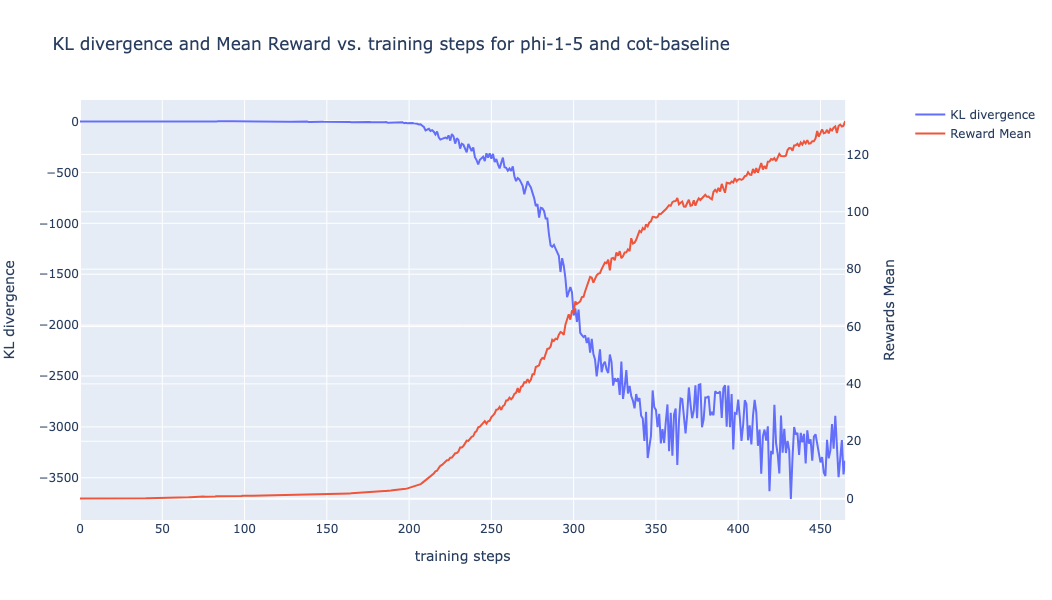

In [36]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create figure with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])
chosen_key = sorted(ppo_telemetry_dict.keys())[0] #'phi-1-5_insights-500'
model = chosen_key.split('_')[0]
run_type = chosen_key.split('_')[1]
n_steps = len(ppo_telemetry_dict[chosen_key]['kl-divergence'])
# Add traces
fig.add_trace(
    go.Scatter(
        x=list(range(n_steps)), y=ppo_telemetry_dict[chosen_key]['kl-divergence'], name="KL divergence"
    ),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(
        x=list(range(n_steps)), y=ppo_telemetry_dict[chosen_key]['returns-mean'], name="Reward Mean"
    ),
    secondary_y=True,
)

# Add figure title
fig.update_layout(
    title_text=f"KL divergence and Mean Reward vs. training steps for {model} and {run_type}"
)

# Set x-axis title
fig.update_xaxes(title_text="training steps")

# Set y-axes titles
fig.update_yaxes(title_text="KL divergence", secondary_y=False)
fig.update_yaxes(title_text="Rewards Mean", secondary_y=True)
fig.update_layout(
    autosize=False,
    width=1_000,
    height=600,
)

fig.show()

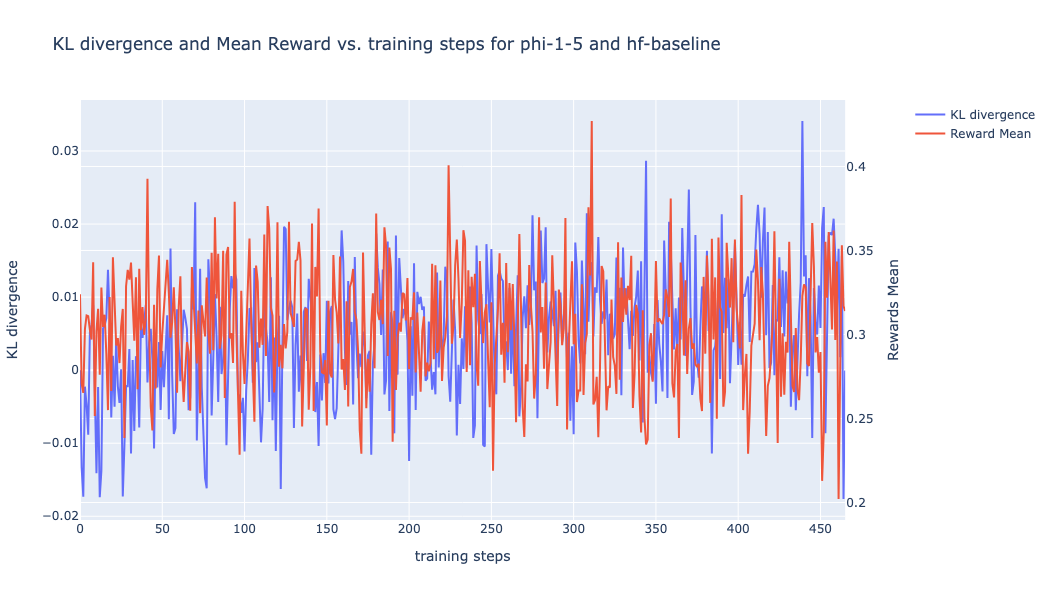

In [37]:
# Create figure with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])
chosen_key = sorted(ppo_telemetry_dict.keys())[1] #'phi-1-5_insights-500'
model = chosen_key.split('_')[0]
run_type = chosen_key.split('_')[1]
n_steps = len(ppo_telemetry_dict[chosen_key]['kl-divergence'])
# Add traces
fig.add_trace(
    go.Scatter(
        x=list(range(n_steps)), y=ppo_telemetry_dict[chosen_key]['kl-divergence'], name="KL divergence"
    ),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(
        x=list(range(n_steps)), y=ppo_telemetry_dict[chosen_key]['returns-mean'], name="Reward Mean"
    ),
    secondary_y=True,
)

# Add figure title
fig.update_layout(
    title_text=f"KL divergence and Mean Reward vs. training steps for {model} and {run_type}"
)

# Set x-axis title
fig.update_xaxes(title_text="training steps")

# Set y-axes titles
fig.update_yaxes(title_text="KL divergence", secondary_y=False)
fig.update_yaxes(title_text="Rewards Mean", secondary_y=True)
fig.update_layout(
    autosize=False,
    width=1_000,
    height=600,
)

fig.show()

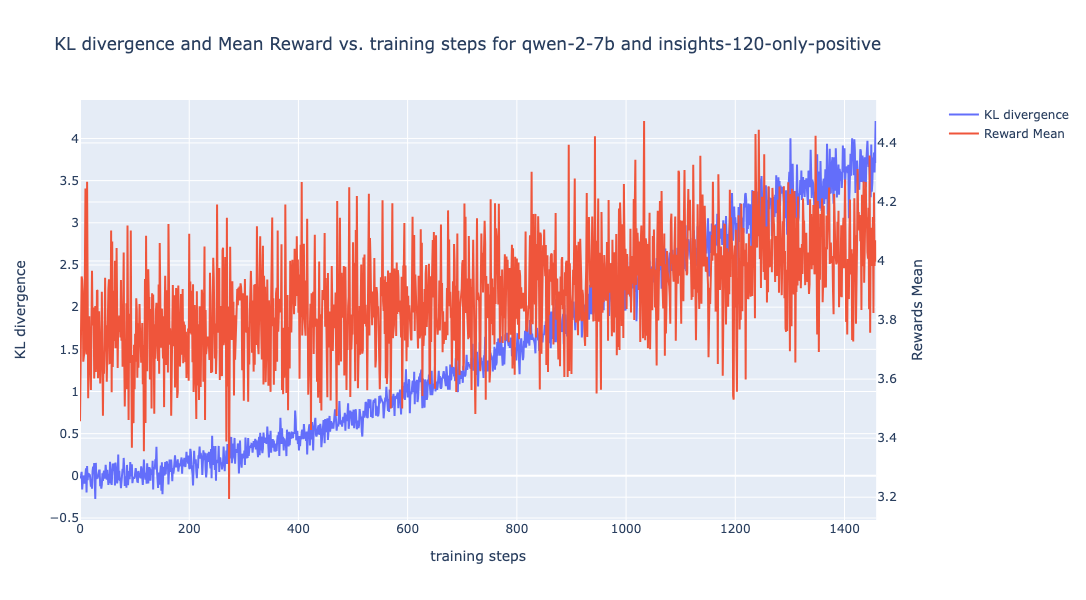

In [63]:
# Create figure with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])
chosen_key = sorted(ppo_telemetry_dict.keys())[1] #'phi-1-5_insights-500'
model = chosen_key.split('_')[0]
run_type = chosen_key.split('_')[1]
n_steps = len(ppo_telemetry_dict[chosen_key]['kl-divergence'])
# Add traces
fig.add_trace(
    go.Scatter(
        x=list(range(n_steps)), y=ppo_telemetry_dict[chosen_key]['kl-divergence'], name="KL divergence"
    ),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(
        x=list(range(n_steps)), y=ppo_telemetry_dict[chosen_key]['returns-mean'], name="Reward Mean"
    ),
    secondary_y=True,
)

# Add figure title
fig.update_layout(
    title_text=f"KL divergence and Mean Reward vs. training steps for {model} and {run_type}"
)

# Set x-axis title
fig.update_xaxes(title_text="training steps")

# Set y-axes titles
fig.update_yaxes(title_text="KL divergence", secondary_y=False)
fig.update_yaxes(title_text="Rewards Mean", secondary_y=True)
fig.update_layout(
    autosize=False,
    width=1_000,
    height=600,
)

fig.show()

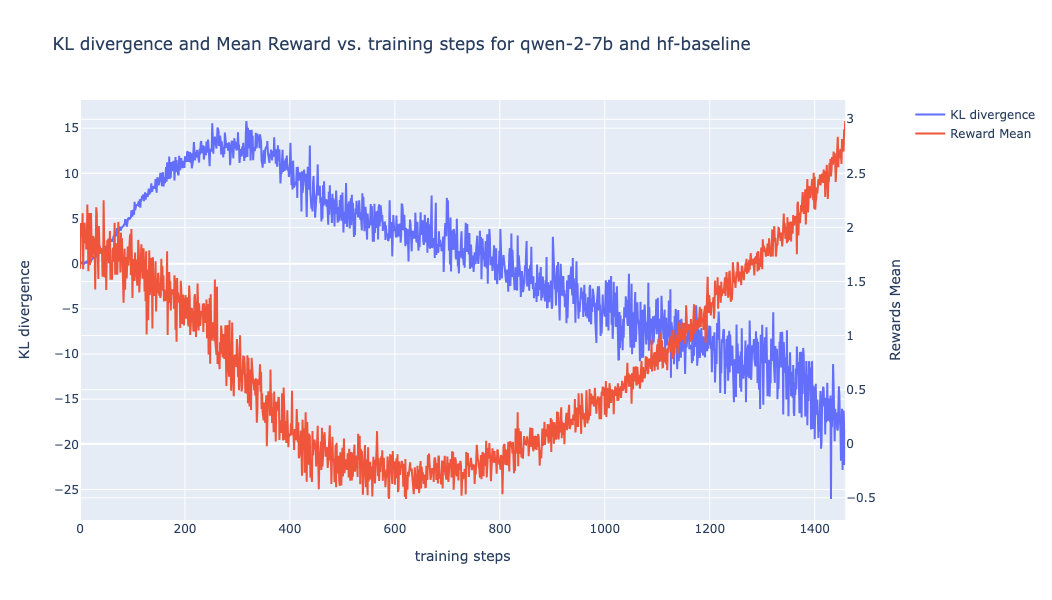

In [49]:
# Create figure with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])
chosen_key = sorted(ppo_telemetry_dict.keys())[7] #'phi-1-5_insights-500'
model = chosen_key.split('_')[0]
run_type = chosen_key.split('_')[1]
n_steps = len(ppo_telemetry_dict[chosen_key]['kl-divergence'])
# Add traces
fig.add_trace(
    go.Scatter(
        x=list(range(n_steps)), y=ppo_telemetry_dict[chosen_key]['kl-divergence'], name="KL divergence"
    ),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(
        x=list(range(n_steps)), y=ppo_telemetry_dict[chosen_key]['returns-mean'], name="Reward Mean"
    ),
    secondary_y=True,
)

# Add figure title
fig.update_layout(
    title_text=f"KL divergence and Mean Reward vs. training steps for {model} and {run_type}"
)

# Set x-axis title
fig.update_xaxes(title_text="training steps")

# Set y-axes titles
fig.update_yaxes(title_text="KL divergence", secondary_y=False)
fig.update_yaxes(title_text="Rewards Mean", secondary_y=True)
fig.update_layout(
    autosize=False,
    width=1_000,
    height=600,
)

fig.show()

In [54]:
final_training_dict = {
    'model': [],
    'run_type': [],
    'kl-divergence': [],
    'reward_mean': [],
}
for key, ppo_eval_dicts in ppo_telemetry_dict.items():
    final_training_dict['reward_mean'].append(ppo_eval_dicts['returns-mean'][-1])
    final_training_dict['kl-divergence'].append(ppo_eval_dicts['kl-divergence'][-1])
    final_training_dict['run_type'].append(key.split('_')[1])
    final_training_dict['model'].append(key.split('_')[0])

pd_df = pd.DataFrame.from_dict(final_training_dict)
pd_df.head()

,model,run_type,kl-divergence,reward_mean
0,qwen-2-7b,hf-baseline,-18.378004,2.983903
1,qwen-2-7b,cot-baseline,-11.685976,5.262119
2,qwen-2-7b,insights-120-only-positive,3.710229,3.997881
3,qwen-2-7b,insights-120-with-negatives,-3.120763,0.365436
4,qwen-2-7b,insights-240,3.041139,-0.587187


Bad pipe message: %s [b'u\xe8\x17\x93\xef34pBf\x00.\xc0\xeaVt\x1b\xf0\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00', b'\x05\x00\x06']
Bad pipe message: %s [b'\xfd\xb8\xe7e\x83\x98\x89CbX\x88\x80\xb5\xf2\xd8@\x05\xf0\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00\x14\x00\x15\x00\x16\x00\x17\x00\x18\x00\x19\x00\x1a\x00\x1b\x00/\x000\x001\x002\x003\x004\x005\x006\x007\x008\x009\x00:\x00;\x00<\x00=\x00>\x00?\x00@\x00A\x00B\x00C\x00D\x00E\x00F\x00g\x00h\x00i\x00j\x00k\x00l\x00m\x00\x84\x00\x85\x00\x86\x00\x87\x00\x88\x00\x89\x00\x96\x00\x97\x00\x98\x00\x99\x00\x9a\x00\x9b']


In [68]:
pd_df.sort_values(['kl-divergence', 'model'], ascending=[False, True], inplace=True)

pd_df.to_csv('ppo-convergence-results.csv')
pd_df.round(4)

,model,run_type,kl-divergence,reward_mean
2,qwen-2-7b,insights-120-only-positive,3.7102,3.9979
4,qwen-2-7b,insights-240,3.0411,-0.5872
8,phi-1-5,insights-120-only-positive,0.0433,-0.2910
10,phi-1-5,insights-240,0.0409,0.2487
9,phi-1-5,insights-120-with-negatives,0.0354,-0.0897
6,phi-1-5,hf-baseline,-0.0001,0.3140
3,qwen-2-7b,insights-120-with-negatives,-3.1208,0.3654
5,qwen-2-7b,insights-500,-4.0741,-0.8495
1,qwen-2-7b,cot-baseline,-11.6860,5.2621
0,qwen-2-7b,hf-baseline,-18.3780,2.9839


In [56]:
ai_eval_results = load_json_files_into_dict(
    models=models_configs,
    file_name='human-vs-ppo-haiku-scores-short',
    # use_model_name_mapping=False,
    # sub_path: str = '03-reward-modelling-and-reinforcement-learning',
)
ai_eval_results['qwen-2-7b_hf-baseline'].keys()

qwen-2-7b hf-baseline e7b8abb8
qwen-2-7b cot-baseline bd978ba4
qwen-2-7b insights-120-only-positive 95620e03
qwen-2-7b insights-120-with-negatives 0c718a7b
qwen-2-7b insights-240 d3ed4259
qwen-2-7b insights-500 3a522f64
phi-1-5 hf-baseline 8e9a5881
phi-1-5 cot-baseline c745c16c
phi-1-5 insights-120-only-positive ccb3bd62
phi-1-5 insights-120-with-negatives dd6d7dba
phi-1-5 insights-240 bbea9d66
phi-1-5 insights-500 64f78115


dict_keys(['human_evals', 'human_prompt_cost', 'human_output_cost', 'sft_evals', 'sft_prompt_cost', 'sft_output_cost'])

## AI eval metrics

In [57]:
# ai_eval_results['qwen-2-7b_hf-baseline']['human_evals'][200], ai_eval_results['qwen-2-7b_hf-baseline']['human_evals'][6]
import re

In [58]:
ai_eval_dict = {'model': [], 'run_type': [], 'human_summary_comparison': [], 'sft_summary_comparison': [], 'human_prompt': [], 
                'sft_prompt': []}

for model_name, ai_dict in ai_eval_results.items():
    # pattern = r'Summary\s+(\d)\s+is\s+preferred|(?:prefer|preferred)[^\d]*(\d)'
    pattern = r'\d+'
    for i in range(len(ai_dict['human_evals'])):
        human_eval = ai_dict['human_evals'][i].lower()
        sft_eval = ai_dict['sft_evals'][i].lower()
        
        sft_matches = re.findall(pattern, sft_eval)
        human_matches = re.findall(pattern, human_eval)
        # for match in matches:
        if sft_matches:
            sft_result = sft_matches[0][0] #if sft_matches[0][0] is True else  'unk' # sft_matches[0][1]
        if human_matches:
            human_result = human_matches[0][0] #if human_matches[0][0] is True else  'unk' # human_matches[0][1]

        ai_eval_dict['human_summary_comparison'].append(human_result)
        ai_eval_dict['sft_summary_comparison'].append(sft_result)
        ai_eval_dict['human_prompt'].append(human_eval)
        ai_eval_dict['sft_prompt'].append(sft_eval)
    
        ai_eval_dict['run_type'].append(model_name.split('_')[1])
        ai_eval_dict['model'].append(model_name.split('_')[0])

ai_eval_pd_df = pd.DataFrame.from_dict(ai_eval_dict)
ai_eval_pd_df['constant'] = 1

In [59]:
sft_matches[0][0], human_matches[0][0]

('2', '2')

In [62]:
ai_eval_pd_df[(ai_eval_pd_df['run_type'] == 'insights-500') & (ai_eval_pd_df['model'] == 'phi-1-5')].head()
# ['human_prompt'].to_list()

,model,run_type,human_summary_comparison,sft_summary_comparison,human_prompt,sft_prompt,constant
7216,phi-1-5,insights-500,2,2,"based on the rationale provided, the preferred...",preferred summary = 2,1
7217,phi-1-5,insights-500,2,2,preferred summary = 2,preferred summary = 2,1
7218,phi-1-5,insights-500,2,2,"based on the provided rationale, the preferred...","based on the rationale provided, the preferred...",1
7219,phi-1-5,insights-500,2,2,preferred summary = 2,the preferred summary is 2.,1
7220,phi-1-5,insights-500,2,2,"based on the provided rationale, the preferred...","based on the provided rationale, the preferred...",1


In [72]:
ai_eval_results_pd_df = ai_eval_pd_df.groupby(["model", "run_type", 'human_summary_comparison', 'sft_summary_comparison'])['constant'].count().reset_index()
# ai_eval_results_pd_df
# ai_eval_results_pd_df.pivot(index=["model", "run_type"], values='constant', columns=['human_summary_comparison'])


eval_human_summaries_pd_df = ai_eval_results_pd_df.pivot_table(values='constant', index=["model", "run_type"], columns=['human_summary_comparison'], aggfunc='sum').reset_index(drop=False)
eval_human_summaries_pd_df['win_rate'] = (eval_human_summaries_pd_df['2'] / (eval_human_summaries_pd_df['1'] + 
                                                                            eval_human_summaries_pd_df['2']))

eval_human_summaries_pd_df.sort_values(['win_rate'], ascending=[False], inplace=True)

eval_human_summaries_pd_df.to_csv('ai-eval-ppo-over-human-summaries.csv')
eval_human_summaries_pd_df.round(4)

human_summary_comparison,model,run_type,1,2,win_rate
1,phi-1-5,hf-baseline,190,466,0.7104
4,phi-1-5,insights-240,192,464,0.7073
3,phi-1-5,insights-120-with-negatives,195,461,0.7027
2,phi-1-5,insights-120-only-positive,196,460,0.7012
10,qwen-2-7b,insights-240,244,412,0.6280
5,phi-1-5,insights-500,250,406,0.6189
0,phi-1-5,cot-baseline,253,403,0.6143
6,qwen-2-7b,cot-baseline,398,258,0.3933
8,qwen-2-7b,insights-120-only-positive,420,236,0.3598
9,qwen-2-7b,insights-120-with-negatives,455,201,0.3064


/Users/gtoth/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/plotly/express/_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/Users/gtoth/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/plotly/io/_renderers.py:395: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.



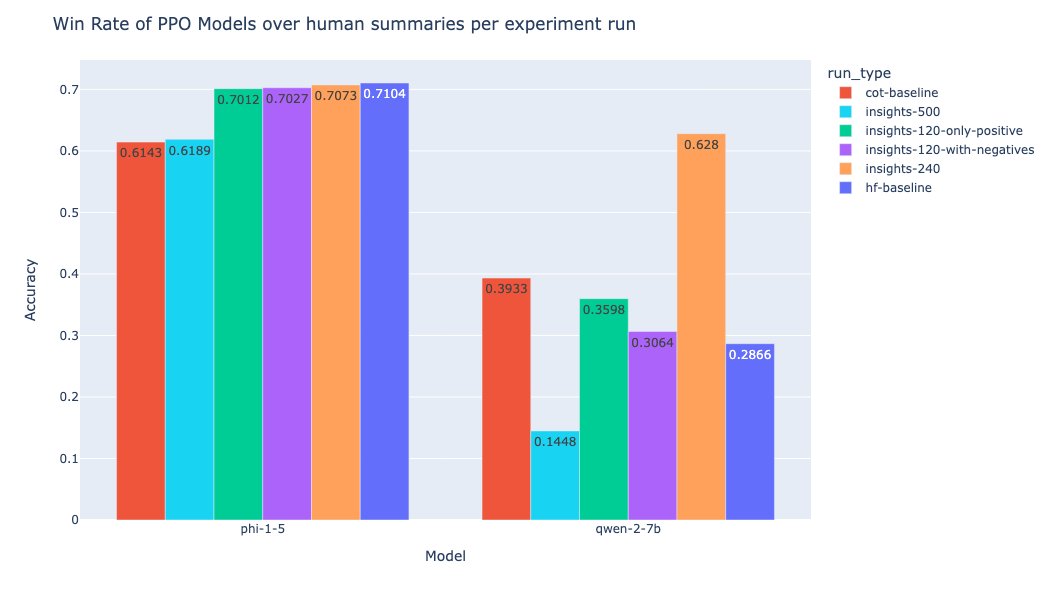

In [70]:
fig = px.bar(
    eval_human_summaries_pd_df.sort_values(['model', 'win_rate'], ascending=[True, True]).round(4),
    x="model",
    y="win_rate",
    color="run_type",
    barmode="group",
    # facet_row="time",
    # facet_col="model",
    # category_orders={"day": ["Thur", "Fri", "Sat", "Sun"],
    #                  "time": ["Lunch", "Dinner"]}
    color_discrete_map=color_map,
    text='win_rate',
)

fig.update_layout(title_text=f"Win Rate of PPO Models over human summaries per experiment run")

# Set x-axis title
fig.update_xaxes(title_text="Model")

# Set y-axes titles
fig.update_yaxes(title_text="Accuracy", secondary_y=False)
# fig.update_yaxes(title_text="Rewards Mean", secondary_y=True)
fig.update_layout(
    autosize=False,
    width=1_000,
    height=600,
)
fig.show()

In [56]:
# ai_eval_results_pd_df = ai_eval_pd_df.groupby(["model", "run_type", 'human_summary_comparison', 'sft_summary_comparison'])['constant'].count().reset_index()

# ai_eval_results_pd_df.pivot(index=["model", "run_type"], values='constant', columns=['human_summary_comparison'])
# ai_eval_results_pd_df.pivot_table(values='constant', index=["model", "run_type"], columns=['human_summary_comparison'], aggfunc='sum')

# df.pivot_table(values=3, index=[0, 1], columns=2, aggfunc='mean')

In [73]:
# ai_eval_results_pd_df.pivot(index=["model", "run_type"], values='constant', columns=['sft_summary_comparison'])

eval_sft_summaries_pd_df = ai_eval_results_pd_df.pivot_table(values='constant', index=["model", "run_type"], columns=['sft_summary_comparison'], aggfunc='sum').reset_index(drop=False)#.columns#.drop('sft_summary_comparison', axis=1)


eval_sft_summaries_pd_df['win_rate'] = (eval_sft_summaries_pd_df['2'] / (eval_sft_summaries_pd_df['1'] + 
                                                                            eval_sft_summaries_pd_df['2']))

eval_sft_summaries_pd_df.sort_values(['win_rate'], ascending=[False], inplace=True)

eval_human_summaries_pd_df.to_csv('ai-eval-ppo-over-sft-summaries.csv')
eval_human_summaries_pd_df.round(4)

human_summary_comparison,model,run_type,1,2,win_rate
1,phi-1-5,hf-baseline,190,466,0.7104
4,phi-1-5,insights-240,192,464,0.7073
3,phi-1-5,insights-120-with-negatives,195,461,0.7027
2,phi-1-5,insights-120-only-positive,196,460,0.7012
10,qwen-2-7b,insights-240,244,412,0.6280
5,phi-1-5,insights-500,250,406,0.6189
0,phi-1-5,cot-baseline,253,403,0.6143
6,qwen-2-7b,cot-baseline,398,258,0.3933
8,qwen-2-7b,insights-120-only-positive,420,236,0.3598
9,qwen-2-7b,insights-120-with-negatives,455,201,0.3064


/Users/gtoth/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/plotly/express/_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/Users/gtoth/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/plotly/io/_renderers.py:395: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.



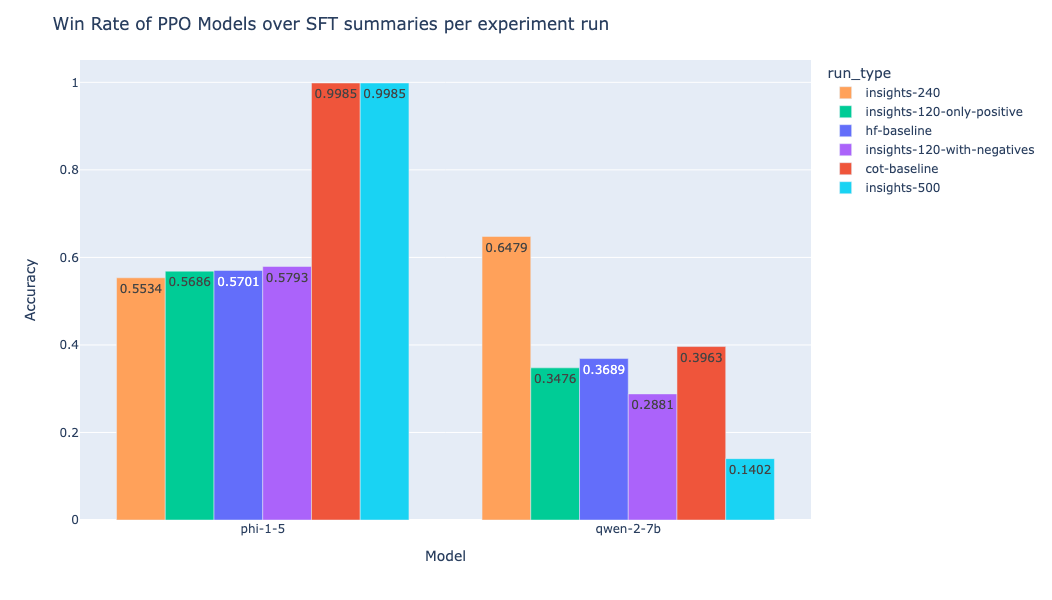

In [75]:
fig = px.bar(
    eval_sft_summaries_pd_df.sort_values(['model', 'win_rate'], ascending=[True, True]).round(4),
    x="model",
    y="win_rate",
    color="run_type",
    barmode="group",
    # facet_row="time",
    # facet_col="model",
    # category_orders={"day": ["Thur", "Fri", "Sat", "Sun"],
    #                  "time": ["Lunch", "Dinner"]}
    color_discrete_map=color_map,
    text='win_rate',
)

fig.update_layout(title_text=f"Win Rate of PPO Models over SFT summaries per experiment run")

# Set x-axis title
fig.update_xaxes(title_text="Model")

# Set y-axes titles
fig.update_yaxes(title_text="Accuracy", secondary_y=False)
# fig.update_yaxes(title_text="Rewards Mean", secondary_y=True)
fig.update_layout(
    autosize=False,
    width=1_000,
    height=600,
)
fig.show()

In [46]:
# # pattern = r'(?:prefer|preferred)[^\d]*(\d)|Summary\s+(\d)\s+is\s+preferred'

# check_list = ai_eval_pd_df[(ai_eval_pd_df['run_type'] == 'insights-500') & (ai_eval_pd_df['model'] == 'phi-1-5')]['human_prompt'].to_list() #[['sft_prompt', 'human_prompt']]
# pattern = r'\d+'  # r'Summary\s+(\d)\s+is\s+preferred|(?:prefer|preferred)[^\d]*(\d)'
# example = check_list[0].lower()
# print(example)

# matches = re.findall(pattern, example)
# for match in matches:
#     # match[0] is the integer before 'prefer/preferred', match[1] is the integer after
#     before = match[0] if match[0] else 'None'
#     # after = match[1] if match[1] else 'None'
#     # print(f"Before: {before}, After: {after}")
#     print(f'Found: {match[0]}',)

# matches, match[0] is True, matches[0][0]

based on the rationale provided, the preferred summary is summary 2. the rationale states that
Found: 2


(['2'], False, '2')

In [ ]:
# import re

# pattern = r'(\d+)\s*(?:\n*)\s*(?:prefer|preferred)|(?:prefer|preferred)\s*(?:\n*)\s*(\d+)'


# text = """1

# Rationale:
# Summary 1 is preferred as it accurately captures the key points of the original text - the narrator's reluctance to restart a friendship that caused them emotional pain, the need to strike a balance between being friendly and distant, and the desire for suggestions on how to handle the situation. It has good coherence, accuracy, and coverage of the important details. Summary 2 is too brief and does not provide enough information to fully represent the original text."""

# # Find all matches
# matches = re.findall(pattern, text)

# # Process and display matches
# for match in matches:
#     # match[0] is the integer before 'prefer/preferred', match[1] is the integer after
#     print(f"Before: {match[0]} After: {match[1]}")# Define the regex pattern
# pattern = r'(\d+)\s*(?:\n*)\s*(?:prefer|preferred)|(?:prefer|preferred)\s*(?:\n*)\s*(\d+)'

# # Sample text
# text = """1

# Rationale:
# Summary 1 is preferred as it accurately captures the key points of the original text - the narrator's reluctance to restart a friendship that caused them emotional pain, the need to strike a balance between being friendly and distant, and the desire for suggestions on how to handle the situation. It has good coherence, accuracy, and coverage of the important details. Summary 2 is too brief and does not provide enough information to fully represent the original text."""

# # Find all matches
# matches = re.findall(pattern, text)

# # Process and display matches
# for match in matches:
#     # match[0] is the integer before 'prefer/preferred', match[1] is the integer after
#     before = match[0] if match[0] else 'None'
#     after = match[1] if match[1] else 'None'
#     print(f"Before: {before}, After: {after}")

# END